In [1]:
import datetime as dt
import pandas as pd
import numpy as np
import warnings
#import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')

In [2]:
def isclose(value, original, tolerance= 0.05):
    return value <= original * (1+tolerance) and value >= original * (1-tolerance)

In [3]:
# see if you can derive the transformations from log returns to simple returns, and simple returns to log returns
hdf = pd.read_parquet('/Users/ishwar/Desktop/Desktop/IEOR198 Final/stock_data.parquet')
hdf.head()

Price        Adj Close                                                        \
Ticker               A    AAL        AAPL        ABBV        ABNB        ABT   
Date                                                                           
2023-10-04  110.917877  12.73  172.585999  141.069550  127.410004  93.262283   
2023-10-05  109.606766  12.85  173.828293  140.840302  124.989998  93.798546   
2023-10-06  109.894814  12.76  176.392334  141.594879  126.360001  94.461571   
2023-10-09  110.530510  12.24  177.883041  142.425888  127.769997  94.344574   
2023-10-10  112.526970  12.26  177.286758  142.215759  131.589996  95.124588   

Price                                                      ...  Volume  \
Ticker           ACGL         ACN        ADBE         ADI  ...     WTW   
Date                                                       ...           
2023-10-04  76.509293  303.237457  518.419983  170.809814  ...  749100   
2023-10-05  77.631355  303.502045  516.440002  169.148819  ...  855000   
2023-10-06  78.144844  305.981781  526.679993  170.986740  ...  897700   
2023-10-09  78.040245  305.805359  529.289978  170.347885  ...  655500   
2023-10-10  77.840553  306.109161  532.719971  172.952438  ...  478400   

Price                                                                       \
Ticker           WY     WYNN      XEL       XOM      XYL      YUM      ZBH   
Date                                                                         
2023-10-04  3954000  2289300  3948700  19622200  1614400  1381200  1597600   
2023-10-05  3724500  1513600  3835400  20128800  1131000  1240200  1048200   
2023-10-06  4318300  2470600  6337200  25363400  1149700  2111900  1570500   
2023-10-09  3171800  1622800  2702100  22369900   949500  1840000   865900   
2023-10-10  3078500  1674800  3117900  13892000  1478800  1643300   999400   

Price                        
Ticker        ZBRA      ZTS  
Date                         
2023-10-04  487500  1673400  
2023-10-05  448400  2083200  
2023-10-06  384000  1490600  
2023-10-09  266600  1215100  
2023-10-10  361900  1665300  

[5 rows x 994 columns]

In [4]:
# use np.exp
def logtosimple(logreturn):
    return np.exp(logreturn) - 1

In [5]:
# use np.log
def simpletolog(simplereturn):
    return np.log(simplereturn + 1)

In [6]:
# let's look at an example asset
# create a dataframe that is just the adjusted close and volume for AAL
aal = hdf.loc[:,hdf.columns.get_level_values(1) == "AAL"]
aal.head()

Price,Adj Close,Volume
Ticker,AAL,AAL
Date,,
2023-10-04,12.73,49738100
2023-10-05,12.85,36272900
2023-10-06,12.76,31822200
2023-10-09,12.24,51462700
2023-10-10,12.26,37144200


Let's remove the top level of the columns in order to make things easier - we already know the symbol is AAL

In [7]:
aal.columns = aal.columns.get_level_values(0)
print(aal.columns)
aal.head()

Index(['Adj Close', 'Volume'], dtype='object', name='Price')


Price,Adj Close,Volume
Date,,
2023-10-04,12.73,49738100
2023-10-05,12.85,36272900
2023-10-06,12.76,31822200
2023-10-09,12.24,51462700
2023-10-10,12.26,37144200


To calculate returns for **AAL**, create a new column by applying `.pct_change()` to the **adjusted close** column.

In [8]:
aal['returns'] = aal["Adj Close"].pct_change()
aal.head()

Price,Adj Close,Volume,returns
Date,,,
2023-10-04,12.73,49738100,NaN
2023-10-05,12.85,36272900,0.009427
2023-10-06,12.76,31822200,-0.007004
2023-10-09,12.24,51462700,-0.040752
2023-10-10,12.26,37144200,0.001634


In [9]:
# we can get the log returns by adjusting the percent change function

aal['logreturns'] = aal['returns'].apply(simpletolog)
aal.head()

Price,Adj Close,Volume,returns,logreturns
Date,,,,
2023-10-04,12.73,49738100,NaN,NaN
2023-10-05,12.85,36272900,0.009427,0.009382
2023-10-06,12.76,31822200,-0.007004,-0.007029
2023-10-09,12.24,51462700,-0.040752,-0.041606
2023-10-10,12.26,37144200,0.001634,0.001633


In [10]:
# .cumsum() on a series will add everything in the column up until that point
# this will give us the log return from the start, to the current index
aal['cum_logreturns'] = aal["logreturns"].cumsum()
aal.head()

Price,Adj Close,Volume,returns,logreturns,cum_logreturns
Date,,,,,
2023-10-04,12.73,49738100,NaN,NaN,NaN
2023-10-05,12.85,36272900,0.009427,0.009382,0.009382
2023-10-06,12.76,31822200,-0.007004,-0.007029,0.002354
2023-10-09,12.24,51462700,-0.040752,-0.041606,-0.039252
2023-10-10,12.26,37144200,0.001634,0.001633,-0.037619


115


<Axes: xlabel='Date'>

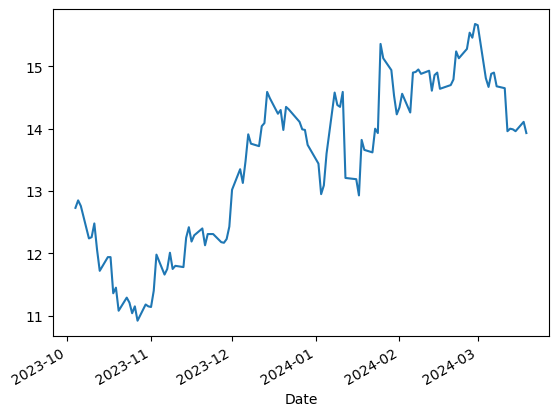

In [11]:
# pandas also comes equipped with some built in plotting
# we can plot the adjusted close, as well as the logreturns cumsum, and see if they look the same (they should)
print(len(aal['Adj Close']))
aal['Adj Close'].plot()

<Axes: xlabel='Date'>

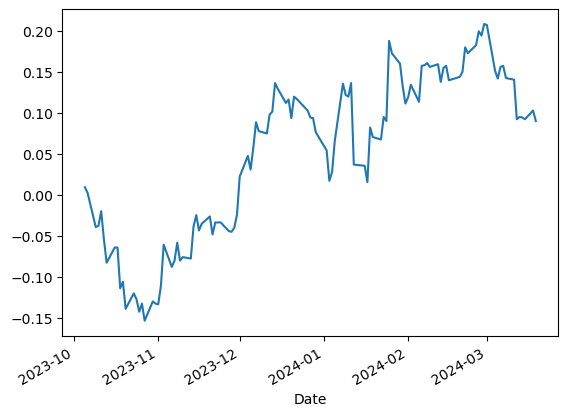

In [12]:
aal['cum_logreturns'].plot()

# Basic trend strategy: long/short by percentile

---
### Developing a Trading Strategy

Now, let’s work on creating a **trading strategy** with the following assumptions:

- **Shorting Allowed**: We assume that we can short stocks.
- **Zero Borrowing Cost**: For simplicity, we assume the cost to borrow is **0** (note: this is a non-trivial assumption).

#### Strategy Overview
Our goal is to:
- **Buy (go long)** stocks expected to increase in value.
- **Sell (go short)** stocks expected to decrease in value.

#### Approach
1. **Ranking Stocks**:  
   We will rank stocks based on a chosen **metric** (e.g., momentum, valuation ratios, or other factors).

2. **Position Allocation**:  
   - Go **long** on the top percentage of stocks ranked by the metric.
   - Go **short** on the bottom percentage of stocks ranked by the metric.

This approach allows us to systematically identify opportunities and construct a portfolio based on clear criteria.

---

In [13]:
hdf

Price        Adj Close                                                         \
Ticker               A    AAL        AAPL        ABBV        ABNB         ABT   
Date                                                                            
2023-10-04  110.917877  12.73  172.585999  141.069550  127.410004   93.262283   
2023-10-05  109.606766  12.85  173.828293  140.840302  124.989998   93.798546   
2023-10-06  109.894814  12.76  176.392334  141.594879  126.360001   94.461571   
2023-10-09  110.530510  12.24  177.883041  142.425888  127.769997   94.344574   
2023-10-10  112.526970  12.26  177.286758  142.215759  131.589996   95.124588   
...                ...    ...         ...         ...         ...         ...   
2024-03-13  147.072739  14.00  170.513031  175.174911  164.759995  118.378120   
2024-03-14  144.475922  13.99  172.376282  176.479996  166.440002  117.087540   
2024-03-15  146.734451  13.96  171.997650  173.246490  160.639999  113.777367   
2024-03-18  145.351471  14.11  173.093674  173.840591  161.860001  110.772606   
2024-03-19  146.644913  13.93  175.445190  174.980118  161.789993  111.481926   

Price                                                      ...  Volume  \
Ticker           ACGL         ACN        ADBE         ADI  ...     WTW   
Date                                                       ...           
2023-10-04  76.509293  303.237457  518.419983  170.809814  ...  749100   
2023-10-05  77.631355  303.502045  516.440002  169.148819  ...  855000   
2023-10-06  78.144844  305.981781  526.679993  170.986740  ...  897700   
2023-10-09  78.040245  305.805359  529.289978  170.347885  ...  655500   
2023-10-10  77.840553  306.109161  532.719971  172.952438  ...  478400   
...               ...         ...         ...         ...  ...     ...   
2024-03-13  86.531769  374.089264  573.549988  197.038223  ...  530100   
2024-03-14  86.560295  373.585510  570.450012  192.901001  ...  482900   
2024-03-15  87.368553  370.019684  492.459991  193.664948  ...  885400   
2024-03-18  86.912125  368.113281  513.859985  189.716248  ...  402800   
2024-03-19  87.168869  373.457092  521.190002  189.041595  ...  579000   

Price                                                                        \
Ticker           WY     WYNN       XEL       XOM      XYL      YUM      ZBH   
Date                                                                          
2023-10-04  3954000  2289300   3948700  19622200  1614400  1381200  1597600   
2023-10-05  3724500  1513600   3835400  20128800  1131000  1240200  1048200   
2023-10-06  4318300  2470600   6337200  25363400  1149700  2111900  1570500   
2023-10-09  3171800  1622800   2702100  22369900   949500  1840000   865900   
2023-10-10  3078500  1674800   3117900  13892000  1478800  1643300   999400   
...             ...      ...       ...       ...      ...      ...      ...   
2024-03-13  2508500  1138400   5420000  17122200   872500  3361400   847000   
2024-03-14  4124900  1882700  11860000  22121000  1335500  3091900  1203900   
2024-03-15  6848900  4404600  11153200  38263900  1537600  4164800  2672400   
2024-03-18  3373100  1528700   7217700  16770500   720000  2384500   972300   
2024-03-19  2496400  1444100   5656800  14878800   806900  2266500   949300   

Price                        
Ticker        ZBRA      ZTS  
Date                         
2023-10-04  487500  1673400  
2023-10-05  448400  2083200  
2023-10-06  384000  1490600  
2023-10-09  266600  1215100  
2023-10-10  361900  1665300  
...            ...      ...  
2024-03-13  286200  5947400  
2024-03-14  375300  6432600  
2024-03-15  539300  3399500  
2024-03-18  329300  4955000  
2024-03-19  306000  3624000  

[115 rows x 994 columns]

In [14]:
# to more easily group by asset, we'll make assets into its own column using df.stack()
hdf_old = hdf.copy()
hdf = (
    hdf.stack()
    .reset_index()
    .rename(columns={'level_1': 'Symbol'})
)
hdf

Price,Date,Ticker,Adj Close,Volume
0,2023-10-04,A,110.917877,1541700.0
1,2023-10-04,AAL,12.730000,49738100.0
2,2023-10-04,AAPL,172.585999,53020300.0
3,2023-10-04,ABBV,141.069550,3159600.0
4,2023-10-04,ABNB,127.410004,5822000.0
...,...,...,...,...
57150,2024-03-19,XYL,127.775208,806900.0
57151,2024-03-19,YUM,135.940338,2266500.0
57152,2024-03-19,ZBH,125.862167,949300.0
57153,2024-03-19,ZBRA,285.190002,306000.0


### Calculating Returns and Log Returns

To compute **returns** and **log returns** for the entire dataset, we can **group by the ticker**, select the adjusted close column, and then use .pct_change() to get the percentage change from one row to the next

These steps will provide the necessary data to derive both simple and log returns for analysis. 

In [15]:
hdf.groupby('Ticker')['Adj Close'].pct_change()

0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
           ...   
57150    0.007530
57151    0.007485
57152    0.005557
57153   -0.002728
57154    0.013299
Name: Adj Close, Length: 57155, dtype: float64

In [16]:
hdf['returns'] = hdf.groupby('Ticker')['Adj Close'].pct_change()
hdf.head()

Price,Date,Ticker,Adj Close,Volume,returns
0,2023-10-04,A,110.917877,1541700.0,NaN
1,2023-10-04,AAL,12.730000,49738100.0,NaN
2,2023-10-04,AAPL,172.585999,53020300.0,NaN
3,2023-10-04,ABBV,141.069550,3159600.0,NaN
4,2023-10-04,ABNB,127.410004,5822000.0,NaN


### Creating a Log Returns Column

To calculate log returns, we'll create a new column in the dataset. This involves applying our **simple-to-log** function to the data and assigning the results to a column named `logreturns`.

This new column will represent the log-transformed returns for each data point.

In [17]:
hdf['logreturns'] = hdf['returns'].apply(simpletolog)
hdf.head()

Price,Date,Ticker,Adj Close,Volume,returns,logreturns
0,2023-10-04,A,110.917877,1541700.0,NaN,NaN
1,2023-10-04,AAL,12.730000,49738100.0,NaN,NaN
2,2023-10-04,AAPL,172.585999,53020300.0,NaN,NaN
3,2023-10-04,ABBV,141.069550,3159600.0,NaN,NaN
4,2023-10-04,ABNB,127.410004,5822000.0,NaN,NaN


### Creating a Forward Log Return Column

To predict the next step of returns, we need to create a column for the **forward log return**. Here's how to do it:

1. **Group by Ticker**: Group the data by the stock ticker to ensure calculations are performed within each stock's data.

2. **Select Log Returns**: Focus on the column containing the log returns.

3. **Shift the Series**: Use `.shift(-1)` to move the series **up one row**, aligning the future return with the current row.  
   Refer to the [pandas.DataFrame.shift documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shift.html) for more details.

This process creates a new column that represents the **forward log return**, which can be used as the target variable for prediction models.

In [18]:
hdf['fwd_logreturn'] = hdf.groupby('Ticker')['logreturns'].shift(-1)
hdf.head()

Price,Date,Ticker,Adj Close,Volume,returns,logreturns,fwd_logreturn
0,2023-10-04,A,110.917877,1541700.0,NaN,NaN,-0.011891
1,2023-10-04,AAL,12.730000,49738100.0,NaN,NaN,0.009382
2,2023-10-04,AAPL,172.585999,53020300.0,NaN,NaN,0.007172
3,2023-10-04,ABBV,141.069550,3159600.0,NaN,NaN,-0.001626
4,2023-10-04,ABNB,127.410004,5822000.0,NaN,NaN,-0.019177


### Dropping Rows with NaN Values

To avoid issues in future operations, we need to drop rows where **log returns** or **forward log returns** contain `NaN` values. This can be done using the `subset` parameter in `df.dropna(subset=[])`

In [19]:
hdf = hdf.dropna(subset=['logreturns', 'fwd_logreturn'])
hdf.head()

Price,Date,Ticker,Adj Close,Volume,returns,logreturns,fwd_logreturn
497,2023-10-05,A,109.606766,1295700.0,-0.011821,-0.011891,0.002625
498,2023-10-05,AAL,12.850000,36272900.0,0.009427,0.009382,-0.007029
499,2023-10-05,AAPL,173.828293,48527900.0,0.007198,0.007172,0.014643
500,2023-10-05,ABBV,140.840302,3599500.0,-0.001625,-0.001626,0.005343
501,2023-10-05,ABNB,124.989998,7630200.0,-0.018994,-0.019177,0.010901


# Momentum

---

### Ranking Returns by Asset

To develop a strategy, we can **rank the returns** for each asset. But first, we need to decide:  

**What metric should we use for ranking?**

#### Observations:
- **Momentum Tendency**:  
  We might guess that stocks that have **gone up** tend to continue rising, while stocks that have **gone down** tend to keep falling.  

#### Why Might This Happen?  
This behavior makes economic sense:
- A stock that has risen significantly might attract buyers who want to **join the trend**, driving the price higher.
- Conversely, a stock that has fallen may face additional selling pressure from investors exiting their positions.

#### Strategy:
- **Buy (Go Long)**: Identify and buy the stocks that have risen the most.  
- **Sell (Go Short)**: Identify and short the stocks that have fallen the most.

---


### Calculating Ranks Using `.rank()`

To calculate ranks for log returns, we can use the `.rank()` method. This method assigns a rank value as if the DataFrame were sorted. Key steps:

1. **Descending Order**: Use `ascending=False` to rank in descending order.
2. **Dense Ranking**: Specify `method='dense'` to ensure that ranks are consecutive even when there are ties.
3. **Group by Date**: Group the data by date to calculate ranks within each group.
4. **Assign to a New Column**: Create a new column, `logreturn_rank`, to store the ranks of the `logreturns` column.

Refer to the [pandas.DataFrame.rank documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rank.html) for more details.

In [20]:
hdf['logreturn_rank'] = hdf.groupby('Date')['logreturns'].rank(ascending=False, method='dense')
hdf.head()

Price,Date,Ticker,Adj Close,Volume,returns,logreturns,fwd_logreturn,logreturn_rank
497,2023-10-05,A,109.606766,1295700.0,-0.011821,-0.011891,0.002625,392.0
498,2023-10-05,AAL,12.850000,36272900.0,0.009427,0.009382,-0.007029,71.0
499,2023-10-05,AAPL,173.828293,48527900.0,0.007198,0.007172,0.014643,99.0
500,2023-10-05,ABBV,140.840302,3599500.0,-0.001625,-0.001626,0.005343,242.0
501,2023-10-05,ABNB,124.989998,7630200.0,-0.018994,-0.019177,0.010901,443.0


In [21]:
pd.set_option('display.max_rows', 200)
#hdf.groupby('Ticker').get_group("AAL")
hdf.groupby('Date').get_group("2023-10-05").sort_values(by=['logreturn_rank'])

Price,Date,Ticker,Adj Close,Volume,returns,logreturns,fwd_logreturn,logreturn_rank
786,2023-10-05,LW,95.649353,7554600.0,0.080230,0.077174,-0.044773,1.0
804,2023-10-05,MKTX,222.038803,787600.0,0.057811,0.056202,0.056525,2.0
613,2023-10-05,CSGP,79.489998,2578700.0,0.040037,0.039256,0.014364,3.0
663,2023-10-05,EQT,40.214714,6080000.0,0.036318,0.035674,0.040540,4.0
835,2023-10-05,NRG,37.469059,4142300.0,0.032835,0.032307,0.007211,5.0
...,...,...,...,...,...,...,...,...
768,2023-10-05,KO,50.808578,29878100.0,-0.048329,-0.049535,0.014405,493.0
861,2023-10-05,PEP,155.269150,10556400.0,-0.052158,-0.053567,0.001186,494.0
592,2023-10-05,CLX,119.689247,7595500.0,-0.052340,-0.053760,0.000560,495.0
797,2023-10-05,MDLZ,63.479565,7626600.0,-0.052563,-0.053994,-0.026631,496.0


In [22]:
# we can also look at the demeaned returns, or the returns of the asset we chose relative to all assets
# this will help us assess if we were able to choose the assets that would end up under/overperforming

date_mean_logreturns = hdf.groupby('Date')['logreturns'].transform('mean')

# Calculate the demeaned log returns
hdf['demeaned_logreturn'] = hdf['logreturns'] - date_mean_logreturns

# Similar to the above, calculate the mean *forward* log returns for each date
date_mean_fwd_logreturns = hdf.groupby('Date')['fwd_logreturn'].transform('mean')

# Calculate the demeaned forward log returns
hdf['demeaned_fwd_logreturn'] = hdf['fwd_logreturn'] - date_mean_fwd_logreturns
hdf.head()

Price,Date,Ticker,Adj Close,Volume,returns,logreturns,fwd_logreturn,logreturn_rank,demeaned_logreturn,demeaned_fwd_logreturn
497,2023-10-05,A,109.606766,1295700.0,-0.011821,-0.011891,0.002625,392.0,-0.008552,-0.005998
498,2023-10-05,AAL,12.850000,36272900.0,0.009427,0.009382,-0.007029,71.0,0.012721,-0.015651
499,2023-10-05,AAPL,173.828293,48527900.0,0.007198,0.007172,0.014643,99.0,0.010511,0.006020
500,2023-10-05,ABBV,140.840302,3599500.0,-0.001625,-0.001626,0.005343,242.0,0.001712,-0.003279
501,2023-10-05,ABNB,124.989998,7630200.0,-0.018994,-0.019177,0.010901,443.0,-0.015838,0.002279


In [23]:
# for ease of analyzing the effect, we will bucket our feature using a decile (each bin is 10%-ile)
# this will help us figure out how strong the effect is
# we do this using pd.qcut(x, q=quantile, labels=False, duplicates='drop'), which cuts a series into quantile buckets. pass q=10 to get decile buckets
# [https://pandas.pydata.org/docs/reference/api/pandas.qcut.html]
# drop labels and duplicates
hdf['logreturn_decile'] = hdf.groupby('Date')['logreturns'].transform(
    lambda x: pd.qcut(x, q=10, labels=False, duplicates='drop'))
hdf.head()

Price,Date,Ticker,Adj Close,Volume,returns,logreturns,fwd_logreturn,logreturn_rank,demeaned_logreturn,demeaned_fwd_logreturn,logreturn_decile
497,2023-10-05,A,109.606766,1295700.0,-0.011821,-0.011891,0.002625,392.0,-0.008552,-0.005998,2
498,2023-10-05,AAL,12.850000,36272900.0,0.009427,0.009382,-0.007029,71.0,0.012721,-0.015651,8
499,2023-10-05,AAPL,173.828293,48527900.0,0.007198,0.007172,0.014643,99.0,0.010511,0.006020,8
500,2023-10-05,ABBV,140.840302,3599500.0,-0.001625,-0.001626,0.005343,242.0,0.001712,-0.003279,5
501,2023-10-05,ABNB,124.989998,7630200.0,-0.018994,-0.019177,0.010901,443.0,-0.015838,0.002279,1


In [24]:
hdf.groupby('logreturn_decile').mean(numeric_only = True)['demeaned_fwd_logreturn']

logreturn_decile
0    0.000197
1    0.000603
2    0.000219
3   -0.000012
4    0.000123
5    0.000040
6   -0.000063
7   -0.000205
8   -0.000251
9   -0.000650
Name: demeaned_fwd_logreturn, dtype: float64

<Axes: xlabel='logreturn_decile'>

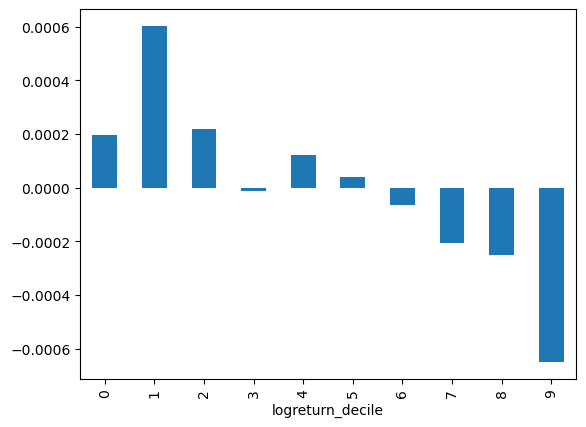

In [25]:
# we'll plot this using a barplot
hdf.groupby('logreturn_decile').mean(numeric_only = True)['demeaned_fwd_logreturn'].plot(kind='bar')

In [26]:
# it definitely looks like the bottom and top 20%-ile have outsized returns!

# Strategy 'backtesting'

---

### Backtesting: A Simplified Approach

While backtesting is a valuable tool, it can sometimes be excessive when conducting an **initial test** to evaluate whether a feature is useful. Instead, we’ll start with a **basic backtest** using the following assumptions:

1. **No Trading Costs**:  
   - We'll ignore trading costs for now.  
   - Although trading costs are a significant drag on profitability, they're not critical for this initial test.

2. **Key Idea**:  
   - If a strategy **doesn’t work** without trading costs, it’s unlikely to work **with** trading costs included.

This simplified backtest provides a quick way to assess the viability of features before diving into more complex analyses.

--- 

In [27]:
# let's define our strategy by setting an asset to be long or short if its in the top or bottom 20% log return decile
# we'll also equal weight all our positions
# the decile values for the bottom 20% would be 0 and 1
# the decile values for the top 20% would be 8 and 9

# we can use np.where() in order to conditionally assign a column
def longorshort(d):
    if d in [0, 1]:
        return 1
    elif d in [8, 9]:
        return -1
    else:
        return 0
hdf['long/short'] = hdf["logreturn_decile"].apply(longorshort)
hdf.head()

Price,Date,Ticker,Adj Close,Volume,returns,logreturns,fwd_logreturn,logreturn_rank,demeaned_logreturn,demeaned_fwd_logreturn,logreturn_decile,long/short
497,2023-10-05,A,109.606766,1295700.0,-0.011821,-0.011891,0.002625,392.0,-0.008552,-0.005998,2,0
498,2023-10-05,AAL,12.850000,36272900.0,0.009427,0.009382,-0.007029,71.0,0.012721,-0.015651,8,-1
499,2023-10-05,AAPL,173.828293,48527900.0,0.007198,0.007172,0.014643,99.0,0.010511,0.006020,8,-1
500,2023-10-05,ABBV,140.840302,3599500.0,-0.001625,-0.001626,0.005343,242.0,0.001712,-0.003279,5,0
501,2023-10-05,ABNB,124.989998,7630200.0,-0.018994,-0.019177,0.010901,443.0,-0.015838,0.002279,1,1


In [28]:
# we size our positions by taking our absolute long/short position
hdf['absposition'] = np.abs(hdf["long/short"])
hdf.head()

Price,Date,Ticker,Adj Close,Volume,returns,logreturns,fwd_logreturn,logreturn_rank,demeaned_logreturn,demeaned_fwd_logreturn,logreturn_decile,long/short,absposition
497,2023-10-05,A,109.606766,1295700.0,-0.011821,-0.011891,0.002625,392.0,-0.008552,-0.005998,2,0,0
498,2023-10-05,AAL,12.850000,36272900.0,0.009427,0.009382,-0.007029,71.0,0.012721,-0.015651,8,-1,1
499,2023-10-05,AAPL,173.828293,48527900.0,0.007198,0.007172,0.014643,99.0,0.010511,0.006020,8,-1,1
500,2023-10-05,ABBV,140.840302,3599500.0,-0.001625,-0.001626,0.005343,242.0,0.001712,-0.003279,5,0,0
501,2023-10-05,ABNB,124.989998,7630200.0,-0.018994,-0.019177,0.010901,443.0,-0.015838,0.002279,1,1,1


In [29]:
# getting the total number of our positions by summing our absolute position for each day 
# hint: take a look at .transform documentation [https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.transform.html]
hdf['numpositions'] = hdf.groupby('Date')['absposition'].transform('sum')
hdf.sort_values(["Ticker", "Date"]).head()

Price,Date,Ticker,Adj Close,Volume,returns,logreturns,fwd_logreturn,logreturn_rank,demeaned_logreturn,demeaned_fwd_logreturn,logreturn_decile,long/short,absposition,numpositions
497,2023-10-05,A,109.606766,1295700.0,-0.011821,-0.011891,0.002625,392.0,-0.008552,-0.005998,2,0,0,200
994,2023-10-06,A,109.894814,1796100.0,0.002628,0.002625,0.005768,367.0,-0.005998,-0.001795,2,0,0,200
1491,2023-10-09,A,110.530510,1320300.0,0.005785,0.005768,0.017901,258.0,-0.001795,0.010052,4,0,0,200
1988,2023-10-10,A,112.526970,2183000.0,0.018063,0.017901,0.000794,77.0,0.010052,-0.001212,8,-1,1,200
2485,2023-10-11,A,112.616356,1381500.0,0.000794,0.000794,-0.039948,296.0,-0.001212,-0.026702,4,0,0,200


In [30]:
# and we get our final weight for each asset by scaling our long/short indicator variable by the number of positions we have
# each position should be such that we add up to one, so we'd divide the indicator by total positions
# if we have 0 positions, the weight should be 0
# this will mean that we should have equal size long and short, adding up to a total of 1 (no leverage)
# we'll use df.apply(lambda row: (expression using row) if (condition on some row) else value, axis=1)

hdf['weight'] = hdf['long/short'] / hdf['numpositions']
hdf.head()

Price,Date,Ticker,Adj Close,Volume,returns,logreturns,fwd_logreturn,logreturn_rank,demeaned_logreturn,demeaned_fwd_logreturn,logreturn_decile,long/short,absposition,numpositions,weight
497,2023-10-05,A,109.606766,1295700.0,-0.011821,-0.011891,0.002625,392.0,-0.008552,-0.005998,2,0,0,200,0.000
498,2023-10-05,AAL,12.850000,36272900.0,0.009427,0.009382,-0.007029,71.0,0.012721,-0.015651,8,-1,1,200,-0.005
499,2023-10-05,AAPL,173.828293,48527900.0,0.007198,0.007172,0.014643,99.0,0.010511,0.006020,8,-1,1,200,-0.005
500,2023-10-05,ABBV,140.840302,3599500.0,-0.001625,-0.001626,0.005343,242.0,0.001712,-0.003279,5,0,0,200,0.000
501,2023-10-05,ABNB,124.989998,7630200.0,-0.018994,-0.019177,0.010901,443.0,-0.015838,0.002279,1,1,1,200,0.005


In [31]:
# finally we define the strategy's return as the weighted logreturns based on our position
# so we multiply weight by forward logreturn
hdf['strategy_logreturn'] = hdf['weight'] * hdf['fwd_logreturn']
hdf.head()

Price,Date,Ticker,Adj Close,Volume,returns,logreturns,fwd_logreturn,logreturn_rank,demeaned_logreturn,demeaned_fwd_logreturn,logreturn_decile,long/short,absposition,numpositions,weight,strategy_logreturn
497,2023-10-05,A,109.606766,1295700.0,-0.011821,-0.011891,0.002625,392.0,-0.008552,-0.005998,2,0,0,200,0.000,0.000000
498,2023-10-05,AAL,12.850000,36272900.0,0.009427,0.009382,-0.007029,71.0,0.012721,-0.015651,8,-1,1,200,-0.005,0.000035
499,2023-10-05,AAPL,173.828293,48527900.0,0.007198,0.007172,0.014643,99.0,0.010511,0.006020,8,-1,1,200,-0.005,-0.000073
500,2023-10-05,ABBV,140.840302,3599500.0,-0.001625,-0.001626,0.005343,242.0,0.001712,-0.003279,5,0,0,200,0.000,0.000000
501,2023-10-05,ABNB,124.989998,7630200.0,-0.018994,-0.019177,0.010901,443.0,-0.015838,0.002279,1,1,1,200,0.005,0.000055


In [32]:
# we can compare this with an equal weighted strategy, where we long each asset the same amount, again summing up to 1
# hint: use .unique() to get number of assets [https://pandas.pydata.org/docs/reference/api/pandas.unique.html]

hdf['eqweight'] = 1 / len(pd.unique(hdf['Ticker']))
hdf['equal_logreturn'] = hdf['eqweight'] * hdf['fwd_logreturn']
hdf.head()

Price,Date,Ticker,Adj Close,Volume,returns,logreturns,fwd_logreturn,logreturn_rank,demeaned_logreturn,demeaned_fwd_logreturn,logreturn_decile,long/short,absposition,numpositions,weight,strategy_logreturn,eqweight,equal_logreturn
497,2023-10-05,A,109.606766,1295700.0,-0.011821,-0.011891,0.002625,392.0,-0.008552,-0.005998,2,0,0,200,0.000,0.000000,0.002012,0.000005
498,2023-10-05,AAL,12.850000,36272900.0,0.009427,0.009382,-0.007029,71.0,0.012721,-0.015651,8,-1,1,200,-0.005,0.000035,0.002012,-0.000014
499,2023-10-05,AAPL,173.828293,48527900.0,0.007198,0.007172,0.014643,99.0,0.010511,0.006020,8,-1,1,200,-0.005,-0.000073,0.002012,0.000029
500,2023-10-05,ABBV,140.840302,3599500.0,-0.001625,-0.001626,0.005343,242.0,0.001712,-0.003279,5,0,0,200,0.000,0.000000,0.002012,0.000011
501,2023-10-05,ABNB,124.989998,7630200.0,-0.018994,-0.019177,0.010901,443.0,-0.015838,0.002279,1,1,1,200,0.005,0.000055,0.002012,0.000022


# Evaluating performance

<Axes: xlabel='Date'>

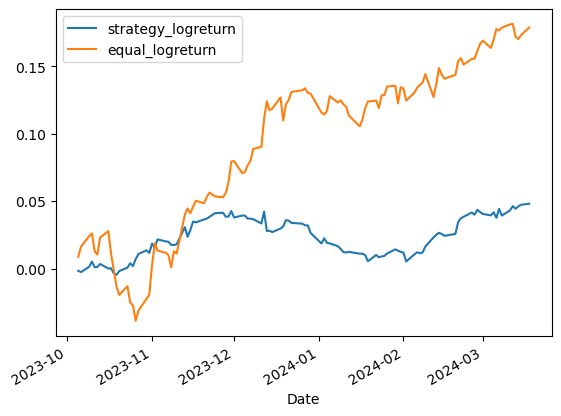

In [33]:
hdf.groupby('Date').sum()['strategy_logreturn'].cumsum().plot(legend=True)
hdf.groupby('Date').sum()['equal_logreturn'].cumsum().plot(legend=True)

In [34]:
# we can get the final return by getting the last value of the column (values[-1])
# and we can translate that to simple returns for readability
final_strategyreturn = logtosimple(hdf.groupby('Date').sum()['strategy_logreturn'].cumsum().values[-1])
final_equalreturn = logtosimple(hdf.groupby('Date').sum()['equal_logreturn'].cumsum().values[-1])

print(f'final_strategyreturn: {final_strategyreturn}')
print(f'final_equalreturn: {final_equalreturn}')

final_strategyreturn: 0.04924253346870078
final_equalreturn: 0.19573618511585034


---

### Evaluating Strategy Performance

The equal-weight strategy significantly outperformed our strategy. Given the simplicity of our approach, this outcome is not unexpected. However, the equal-weight strategy also exhibited notable **volatility**. 

To better account for volatility, we can use the **Sharpe Ratio**. 

#### Understanding the Sharpe Ratio
The Sharpe Ratio measures the **risk-adjusted return** of a strategy and can be thought of as a t-test for the statistical significance of the returns. It is calculated as:  

$$ \text{Sharpe Ratio} = \frac{\text{Mean Return} - \text{Risk-Free Rate}}{\text{Standard Deviation of Returns}}$$

Benerally, any sharpe ratio over 1 is good, 2 is very good, 3+ is very very good. As you see a sharpe ratio > 3, the more likely that the strategy is somehow limited, or you've calculated something wrong

#### Important Caveats
In this example, the calculated Sharpe Ratios are **not realistic** due to several simplifications. For instance:
- **Lookahead Bias**: Restricting the universe to companies currently in the S&P 500 introduces bias, as we are using information unavailable in past periods (e.g., in 2023).

There are likely other ways this sample or testing strategy might be limited. Consider exploring additional potential biases or flaws in the approach!

--- 

In [35]:
# let's calculate the sharpe ratio with a function, we'll leave out the risk free rate part of it for now
# we also need to normalize the sharpe ratio with respect to a year, by multiplying by the square root of periods our strategy trades in a year
# note that there are 252 trading days

def sharpe_ratio(mean_ret, std_ret):
    return (mean_ret / std_ret) * np.sqrt(252)
    
strat_sharpe = sharpe_ratio(hdf.groupby('Date').sum()['strategy_logreturn'].mean(), \
            hdf.groupby('Date').sum()['strategy_logreturn'].std())
equal_sharpe = sharpe_ratio(hdf.groupby('Date').sum()['equal_logreturn'].mean(), \
            hdf.groupby('Date').sum()['equal_logreturn'].std())
print(strat_sharpe, equal_sharpe)

1.840395868545438 3.1044873685151626


# My Strategy: Fourier analysis on log returns

In [36]:
# ---------------------------------------------------------------------
# Configuration for the Fourier strategy -- the only place to edit numbers
# ---------------------------------------------------------------------
FOURIER_CFG = {
    # wavelengths (periods, in trading days) to fit and compare.
    # predict_fwd_logreturn tries each and keeps whichever predicts best.
    "periods":     list(range(12, 6, -1)),   # [12, 11, 10, 9, 8, 7]

    # days held back to score each candidate wavelength
    "test_len":    12,

    # which frequency components to keep after the FFT:
    #   "all"       -> keep everything (current behaviour)
    #   "amplitude" -> keep components with |amp| >= amp_cutoff * strongest
    #   "band"      -> keep only components with wavelength in [band_lo, band_hi]
    "freq_filter": "all",
    "amp_cutoff":  0.0,      # used when freq_filter == "amplitude"
    "band_lo":     4,        # used when freq_filter == "band", in days
    "band_hi":     30,
}

def with_cfg(**overrides):
    """A copy of FOURIER_CFG with a few keys changed, for sweeps."""
    return {**FOURIER_CFG, **overrides}

def warmup_days(cfg):
    """History each prediction needs: longest period + the held-back window."""
    return max(cfg["periods"]) + cfg["test_len"]


In [37]:
# take a single asset
# take the list of log returns associated with the asset
aapl = hdf.groupby("Ticker").get_group("EQR")["logreturns"]
#aapl = aapl[0:len(aapl)//2]
aapl = aapl.to_numpy()
# plot it

# take the first half and perform fft
def perform_fft(sequence):
    # Perform the Fast Fourier Transform
    fft_result = np.fft.fft(sequence)
    # Compute the corresponding frequencies
    n = len(sequence)
    freq = np.fft.fftfreq(n)
    return freq, fft_result
def recover_signal(fft_result):
    # Perform the Inverse Fast Fourier Transform to recover the original signal
    recovered_signal = np.fft.ifft(fft_result)
    return np.real(recovered_signal)  # Return only the real part (original signal)
def extrapolate_signal(fft_result, num_points):
    # Extend the FFT result by zero-padding to extrapolate the time series
    n = len(fft_result)
    extended_fft = np.zeros(num_points, dtype=complex)
    extended_fft[:n] = fft_result

    # Perform the inverse FFT on the extended data
    extrapolated_signal = np.fft.ifft(extended_fft)
    return np.real(extrapolated_signal)  # Return only the real part

"""
window_len = 24
freq, fft_result = perform_fft(aapl[:window_len])
fft_result[7:len(aapl)-7] = 0
#print(fft_result)
#print(freq)
aapl_fourier = recover_signal(fft_result)

plt.plot(range(0, len(aapl_fourier))[:window_len], aapl[:window_len])
print(len(aapl))
plt.plot(range(0, len(aapl_fourier))[:window_len], aapl_fourier[:window_len])
plt.legend(loc="upper right")
plt.show()

plt.plot(range(0, len(aapl)), aapl)
print(len(aapl) // window_len)
#print(np.concatenate(2 * (aapl_fourier,)))
plt.plot(range(0, len(aapl)), np.concatenate((1 + len(aapl)//window_len)*(aapl_fourier,))[0:len(aapl)] )
plt.legend(loc="upper right")
plt.show()
"""

"""
plt.plot(freq[:len(freq)//2], np.abs(fft_result)[:len(freq)//2])
plt.title("FFT Result (Magnitude)")
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.show()
"""
# plot the waveform from the fft onto the full data and see if there is any predictive power

'\nplt.plot(freq[:len(freq)//2], np.abs(fft_result)[:len(freq)//2])\nplt.title("FFT Result (Magnitude)")\nplt.xlabel("Frequency")\nplt.ylabel("Magnitude")\nplt.show()\n'

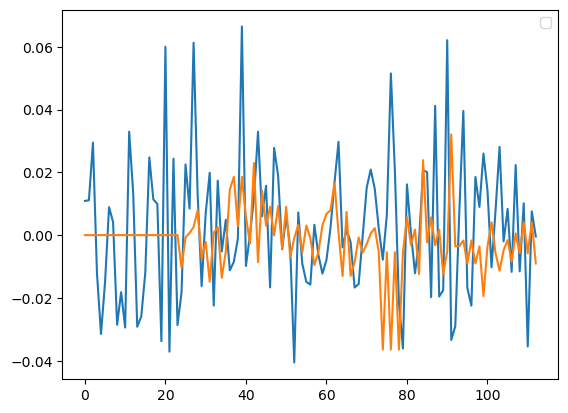

In [38]:
# eliminate high frequency components with wavelength <= 3
"""
cutoff_wavelength = 5
cutoff_freq = 1/cutoff_wavelength
cutoff_n = l // cutoff_wavelength
fft_result[:cutoff_n:] = 0
fft_result[l-cutoff_n:] = 0
"""

def filter_frequencies(fft_result, cfg):
    """Zero out the FFT components the config says to discard."""
    mode = cfg["freq_filter"]
    if mode == "all":
        return fft_result

    n = len(fft_result)
    if mode == "amplitude":
        max_amp = np.max(np.abs(fft_result))
        fft_result[np.abs(fft_result) < max_amp * cfg["amp_cutoff"]] = 0
    elif mode == "band":
        # bin k and bin n-k are conjugates for the same frequency, so fold them:
        # effective wavelength is n / min(k, n-k), and bin 0 is the mean
        k = np.arange(n)
        eff_k = np.minimum(k, n - k)
        wavelength = np.divide(n, eff_k, out=np.full(n, np.inf), where=eff_k > 0)
        keep = (wavelength >= cfg["band_lo"]) & (wavelength <= cfg["band_hi"])
        keep[0] = True                       # always keep the mean term
        fft_result[~keep] = 0
    else:
        raise ValueError(f"unknown freq_filter: {mode!r}")
    return fft_result


def predict_fwd_logreturn(windowed_series, cfg=None):
    cfg = FOURIER_CFG if cfg is None else cfg
    test_len = cfg["test_len"]

    best_mse, best_pred = np.inf, 0.0
    for l in cfg["periods"]:
        # fit on the l days sitting just before the held-back window
        to_fit = windowed_series[-l - test_len:-test_len]
        freq, fft_result = perform_fft(to_fit)
        fft_result = filter_frequencies(fft_result, cfg)
        lowpass_signal = recover_signal(fft_result)

        # tile the recovered wave forward over the held-back window plus one day
        reps = (l + test_len + 1 + l) // l
        extended_signal = np.concatenate(reps * (lowpass_signal,))[:l + test_len + 1]

        mse = np.mean(np.square(extended_signal[-test_len - 1:-1] - windowed_series[-test_len:]))
        if mse < best_mse:
            best_mse, best_pred = mse, extended_signal[-1]
    return best_pred


def calculate_positions(single_asset, cfg=None):
    cfg = FOURIER_CFG if cfg is None else cfg
    window_len = warmup_days(cfg)            # was hard-coded 24
    series = single_asset.to_numpy()
    fwds = np.zeros(len(series))
    for i in range(window_len, len(series)):
        fwds[i] = predict_fwd_logreturn(series[i - window_len:i], cfg)
    return fwds


def run_newstrat(frame, cfg=None):
    """Cells 54, 56 and 58 in one call. Returns the daily portfolio log return."""
    cfg = FOURIER_CFG if cfg is None else cfg
    frame["newstrat_predictedlogret"] = frame.groupby("Ticker")["logreturns"].transform(
        lambda s: calculate_positions(s, cfg))
    frame["newstrat_abspos"]    = frame.groupby("Date")["newstrat_predictedlogret"].transform(np.abs)
    frame["newstrat_totalpos"]  = frame.groupby("Date")["newstrat_abspos"].transform(np.sum)
    frame["newstrat_weight"]    = frame["newstrat_predictedlogret"] / frame["newstrat_totalpos"]
    frame["newstrat_logreturn"] = frame["newstrat_weight"] * frame["fwd_logreturn"]
    return frame.groupby("Date")["newstrat_logreturn"].sum()


asset_fwdlogreturns = hdf.groupby("Ticker").get_group("ABNB")["fwd_logreturn"]
asset_fwd = calculate_positions(hdf.groupby("Ticker").get_group("AAPL")["logreturns"])

plt.plot(range(0, len(asset_fwdlogreturns)), asset_fwdlogreturns)
plt.plot(range(0, len(asset_fwdlogreturns)), asset_fwd)
plt.legend(loc="upper right")
plt.show()

#hdf["newstrat_longshort"] = hdf.groupby("Ticker")["logreturns"].transform(calculate_positions)

In [39]:
hdf["newstrat_predictedlogret"] = hdf.groupby("Ticker")["logreturns"].transform(calculate_positions)

In [40]:
hdf.tail(10)

Price,Date,Ticker,Adj Close,Volume,returns,logreturns,fwd_logreturn,logreturn_rank,demeaned_logreturn,demeaned_fwd_logreturn,logreturn_decile,long/short,absposition,numpositions,weight,strategy_logreturn,eqweight,equal_logreturn,newstrat_predictedlogret
56648,2024-03-18,WTW,271.214355,402800.0,0.006876,0.006853,-0.003219,149.0,0.003870,-0.008853,7,0,0,200,0.000,-0.000000,0.002012,-0.000006,-0.002325
56649,2024-03-18,WY,33.697689,3373100.0,-0.005243,-0.005257,0.011066,401.0,-0.008240,0.005432,1,1,1,200,0.005,0.000055,0.002012,0.000022,0.003654
56650,2024-03-18,WYNN,97.998962,1528700.0,-0.002523,-0.002526,0.009165,360.0,-0.005509,0.003531,2,0,0,200,0.000,0.000000,0.002012,0.000018,-0.008268
56651,2024-03-18,XEL,51.073341,7217700.0,0.000962,0.000961,0.007466,283.0,-0.002021,0.001832,4,0,0,200,0.000,0.000000,0.002012,0.000015,0.006840
56652,2024-03-18,XOM,109.604904,16770500.0,0.009257,0.009214,0.007010,109.0,0.006232,0.001376,7,0,0,200,0.000,0.000000,0.002012,0.000014,0.013663
56653,2024-03-18,XYL,126.820251,720000.0,0.001729,0.001727,0.007502,263.0,-0.001256,0.001868,4,0,0,200,0.000,0.000000,0.002012,0.000015,-0.004928
56654,2024-03-18,YUM,134.930374,2384500.0,-0.004165,-0.004174,0.007457,382.0,-0.007157,0.001823,2,0,0,200,0.000,0.000000,0.002012,0.000015,0.009511
56655,2024-03-18,ZBH,125.166573,972300.0,0.006312,0.006292,0.005542,162.0,0.003309,-0.000092,6,0,0,200,0.000,0.000000,0.002012,0.000011,-0.010776
56656,2024-03-18,ZBRA,285.970001,329300.0,0.000385,0.000385,-0.002731,295.0,-0.002598,-0.008365,4,0,0,200,0.000,-0.000000,0.002012,-0.000005,-0.008233
56657,2024-03-18,ZTS,169.399384,4955000.0,-0.010894,-0.010954,0.013211,461.0,-0.013937,0.007577,0,1,1,200,0.005,0.000066,0.002012,0.000027,-0.003198


In [41]:
# give weights to newstrat weights
hdf["newstrat_abspos"] = hdf.groupby("Date")["newstrat_predictedlogret"].transform(np.abs)
hdf["newstrat_totalpos"] = hdf.groupby("Date")["newstrat_abspos"].transform(np.sum)
hdf["newstrat_weight"] = hdf["newstrat_predictedlogret"] / hdf["newstrat_totalpos"]

In [42]:
hdf.tail()

Price,Date,Ticker,Adj Close,Volume,returns,logreturns,fwd_logreturn,logreturn_rank,demeaned_logreturn,demeaned_fwd_logreturn,...,absposition,numpositions,weight,strategy_logreturn,eqweight,equal_logreturn,newstrat_predictedlogret,newstrat_abspos,newstrat_totalpos,newstrat_weight
56653,2024-03-18,XYL,126.820251,720000.0,0.001729,0.001727,0.007502,263.0,-0.001256,0.001868,...,0,200,0.000,0.000000,0.002012,0.000015,-0.004928,0.004928,4.603442,-0.001070
56654,2024-03-18,YUM,134.930374,2384500.0,-0.004165,-0.004174,0.007457,382.0,-0.007157,0.001823,...,0,200,0.000,0.000000,0.002012,0.000015,0.009511,0.009511,4.603442,0.002066
56655,2024-03-18,ZBH,125.166573,972300.0,0.006312,0.006292,0.005542,162.0,0.003309,-0.000092,...,0,200,0.000,0.000000,0.002012,0.000011,-0.010776,0.010776,4.603442,-0.002341
56656,2024-03-18,ZBRA,285.970001,329300.0,0.000385,0.000385,-0.002731,295.0,-0.002598,-0.008365,...,0,200,0.000,-0.000000,0.002012,-0.000005,-0.008233,0.008233,4.603442,-0.001789
56657,2024-03-18,ZTS,169.399384,4955000.0,-0.010894,-0.010954,0.013211,461.0,-0.013937,0.007577,...,1,200,0.005,0.000066,0.002012,0.000027,-0.003198,0.003198,4.603442,-0.000695


In [43]:
# calculate return of this strategy
hdf['newstrat_logreturn'] = hdf['newstrat_weight'] * hdf['fwd_logreturn']

<Axes: xlabel='Date'>

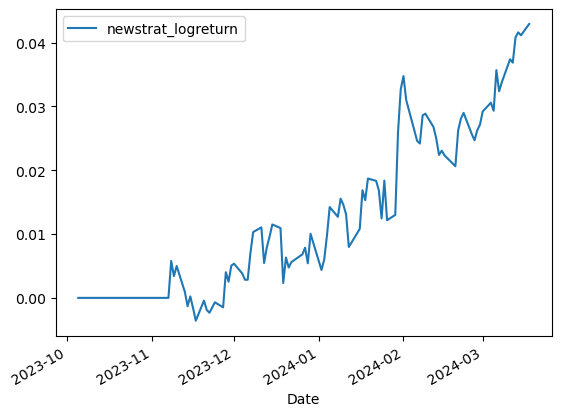

In [44]:
#hdf.groupby('Date').sum()['strategy_logreturn'].cumsum().plot(legend=True)
#hdf.groupby('Date').sum()['equal_logreturn'].cumsum().plot(legend=True)
hdf.groupby('Date').sum()['newstrat_logreturn'].cumsum().plot(legend=True)

<Axes: xlabel='Date'>

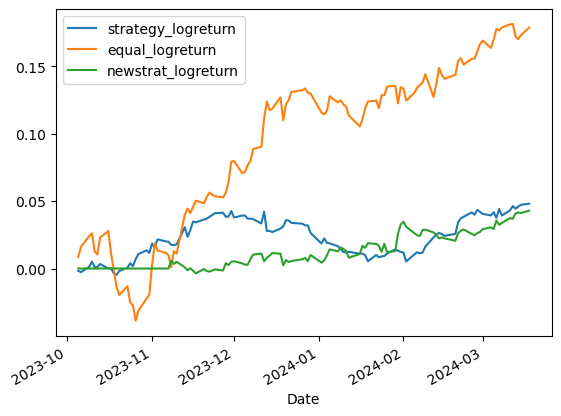

In [45]:
hdf.groupby('Date').sum()['strategy_logreturn'].cumsum().plot(legend=True)
hdf.groupby('Date').sum()['equal_logreturn'].cumsum().plot(legend=True)
hdf.groupby('Date').sum()['newstrat_logreturn'].cumsum().plot(legend=True)

In [46]:
my_sharpe = sharpe_ratio(hdf.groupby('Date').sum()['newstrat_logreturn'].mean(), \
            hdf.groupby('Date').sum()['newstrat_logreturn'].std())
my_sharpe

2.0053076618020373

## Make train/test split and compare approaches & parameter settings

In [66]:
# ---- label every date train / test, 80/20 by time ----
# calculate_positions leaves the first window_len days of each ticker at zero, so
# those dates hold no position at all -- tag them separately and leave them out.
WARMUP = warmup_days(FOURIER_CFG)
SEED = 42

live_dates = sorted(hdf["Date"].unique())[WARMUP:]
n_train = int(len(live_dates) * 0.8)

rng = np.random.default_rng(SEED)
perm = rng.permutation(len(live_dates))
train_set = {live_dates[i] for i in perm[:n_train]}

hdf["split"] = np.where(~hdf["Date"].isin(live_dates), "warmup",
                np.where(hdf["Date"].isin(train_set), "train", "test"))

# ---- measure each half ----
for name in ["train", "test"]:
    daily = hdf[hdf["split"] == name].groupby("Date")["newstrat_logreturn"].sum()
    eq = hdf[hdf["split"] == name].groupby("Date")["equal_logreturn"].sum()
    print(f"{name:6s} {len(daily):3d} days  "
          f"{str(daily.index[0])[:10]} -> {str(daily.index[-1])[:10]}")
    print(f"       newstrat : mean {daily.mean():9.6f}   cum {daily.sum():7.4f}   "
          f"sharpe {sharpe_ratio(daily.mean(), daily.std()):5.2f}")
    print(f"       equal wt : mean {eq.mean():9.6f}   cum {eq.sum():7.4f}   "
          f"sharpe {sharpe_ratio(eq.mean(), eq.std()):5.2f}")


train   71 days  2023-11-08 -> 2024-03-18
       newstrat : mean  0.000659   cum  0.0468   sharpe  3.04
       equal wt : mean  0.001983   cum  0.1408   sharpe  4.21
test    18 days  2023-11-20 -> 2024-03-05
       newstrat : mean -0.000214   cum -0.0038   sharpe -1.08
       equal wt : mean  0.001559   cum  0.0281   sharpe  3.30


In [ ]:
"""
APPROACHES = [
    ("baseline",       FOURIER_CFG),
    ("amp cutoff .25", with_cfg(freq_filter="amplitude", amp_cutoff=0.25)),
    ("amp cutoff .50", with_cfg(freq_filter="amplitude", amp_cutoff=0.50)),
    ("band 6-12d",     with_cfg(freq_filter="band", band_lo=6, band_hi=12)),
    ("periods 15-8",   with_cfg(periods=list(range(15, 7, -1)))),
    ("test_len 8",     with_cfg(test_len=8)),
]
"""
APPROACHES = [
    ("baseline",       FOURIER_CFG),
    ("periods 7-4",   with_cfg(periods=list(range(7, 3, -1)), test_len=8)),
    ("periods 9-5",   with_cfg(periods=list(range(9, 4, -1)))),
    ("periods 15-8",   with_cfg(periods=list(range(15, 7, -1)))),
    ("periods 18-10",   with_cfg(periods=list(range(18, 9, -1)))),
]

# every approach must be scored on the SAME dates, so burn in on the longest
# warm-up in the list rather than each config's own
COMMON_WARMUP = max(warmup_days(cfg) for _, cfg in APPROACHES)

work = hdf.sort_values(["Ticker", "Date"]).copy()

SPLIT_MODE = "chronological"        # "chronological" or "random"
SEED = 42
TRAIN_FRAC = 0.5
live_dates = sorted(work["Date"].unique())[COMMON_WARMUP:]
n_train = int(len(live_dates) * TRAIN_FRAC)
if SPLIT_MODE == "chronological":
    train_dates, test_dates = live_dates[:n_train], live_dates[n_train:]
else:
    rng = np.random.default_rng(SEED)
    perm = rng.permutation(len(live_dates))
    train_dates = [live_dates[i] for i in sorted(perm[:n_train])]
    test_dates  = [live_dates[i] for i in sorted(perm[n_train:])]

rows = []
for name, cfg in APPROACHES:
    daily = run_newstrat(work, cfg)                  # daily portfolio log return, all dates
    tr, te = daily.loc[train_dates], daily.loc[test_dates]

    rows.append({
        "approach":     name,
        "train_mean":   tr.mean(),
        "train_cum":    tr.sum(),
        "train_sharpe": sharpe_ratio(tr.mean(), tr.std()),
        "test_mean":    te.mean(),
        "test_cum":     te.sum(),
        "test_sharpe":  sharpe_ratio(te.mean(), te.std()),
        "periods":      f"{max(cfg['periods'])}-{min(cfg['periods'])}",
        "test_len":     cfg["test_len"],
    })

results = pd.DataFrame(rows)
print(f"warm-up {COMMON_WARMUP} days dropped | "
      f"train {len(train_dates)} days | test {len(test_dates)} days")
print(results.round(6).to_string(index=False))


warm-up 30 days dropped | train 41 days | test 42 days
     approach  train_mean  train_cum  train_sharpe  test_mean  test_cum  test_sharpe periods  test_len
     baseline    0.000406   0.016632      2.016922   0.000620  0.026050     2.732720    12-7        12
  periods 7-4   -0.001670  -0.068465     -6.050513   0.000289  0.012147     1.252754     7-4         8
  periods 9-5    0.000523   0.021462      1.876695  -0.000119 -0.004993    -0.597808     9-5        12
 periods 15-8    0.000686   0.028141      3.694733   0.000649  0.027253     3.766769    15-8        12
periods 18-10    0.000290   0.011870      1.381355   0.000931  0.039107     5.667781   18-10        12


In [ ]:
PERIOD_SETS = [
    ("12-7",  list(range(12, 6, -1))),
    ("7-4",   list(range(7, 3, -1))),
    ("9-5",   list(range(9, 4, -1))),
    ("15-8",  list(range(15, 7, -1))),
    ("18-10", list(range(18, 9, -1))),
]
TEST_LENS = list(range(12, 5, -1))       # 12, 11, 10, 9, 8, 7, 6

APPROACHES = [
    (f"periods {plabel}, test_len {tl}", with_cfg(periods=plist, test_len=tl))
    for plabel, plist in PERIOD_SETS
    for tl in TEST_LENS
]                                        # 5 x 7 = 35 approaches

# every approach must be scored on the SAME dates, so burn in on the longest
# warm-up in the list rather than each config's own
COMMON_WARMUP = max(warmup_days(cfg) for _, cfg in APPROACHES)

work = hdf.sort_values(["Ticker", "Date"]).copy()

SPLIT_MODE = "chronological"        # "chronological" or "random"
SEED = 42
TRAIN_FRAC = 0.5
live_dates = sorted(work["Date"].unique())[COMMON_WARMUP:]
n_train = int(len(live_dates) * TRAIN_FRAC)
if SPLIT_MODE == "chronological":
    train_dates, test_dates = live_dates[:n_train], live_dates[n_train:]
else:
    rng = np.random.default_rng(SEED)
    perm = rng.permutation(len(live_dates))
    train_dates = [live_dates[i] for i in sorted(perm[:n_train])]
    test_dates  = [live_dates[i] for i in sorted(perm[n_train:])]

rows = []
for name, cfg in APPROACHES:
    daily = run_newstrat(work, cfg)                  # daily portfolio log return, all dates
    tr, te = daily.loc[train_dates], daily.loc[test_dates]

    rows.append({
        "approach":     name,
        "train_mean":   tr.mean(),
        "train_cum":    tr.sum(),
        "train_sharpe": sharpe_ratio(tr.mean(), tr.std()),
        "test_mean":    te.mean(),
        "test_cum":     te.sum(),
        "test_sharpe":  sharpe_ratio(te.mean(), te.std()),
        "periods":      f"{max(cfg['periods'])}-{min(cfg['periods'])}",
        "test_len":     cfg["test_len"],
    })

results = pd.DataFrame(rows)
print(f"warm-up {COMMON_WARMUP} days dropped | "
      f"train {len(train_dates)} days | test {len(test_dates)} days")
print(results.round(6).to_string(index=False))


warm-up 30 days dropped | train 41 days | test 42 days
                  approach  train_mean  train_cum  train_sharpe  test_mean  test_cum  test_sharpe periods  test_len
 periods 12-7, test_len 12    0.000406   0.016632      2.016922   0.000620  0.026050     2.732720    12-7        12
 periods 12-7, test_len 11    0.000154   0.006334      0.729129   0.000546  0.022951     2.507404    12-7        11
 periods 12-7, test_len 10    0.000355   0.014535      1.155557   0.000616  0.025889     3.362355    12-7        10
  periods 12-7, test_len 9    0.000666   0.027315      2.273784   0.000501  0.021030     2.485657    12-7         9
  periods 12-7, test_len 8    0.000466   0.019125      1.610759   0.000261  0.010979     1.227445    12-7         8
  periods 12-7, test_len 7    0.000522   0.021402      1.669350   0.000405  0.016991     2.130761    12-7         7
  periods 12-7, test_len 6    0.000901   0.036949      2.740392   0.000132  0.005536     0.686297    12-7         6
  periods 7-4, te

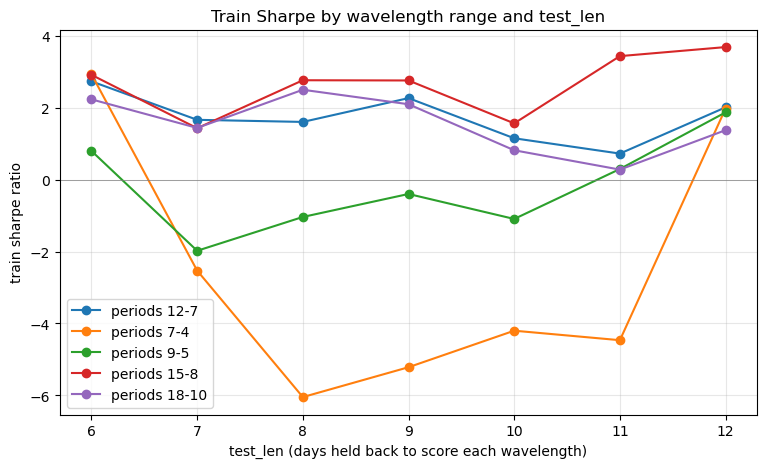

In [69]:
plt.figure(figsize=(9, 5))
for label, grp in results.groupby("periods", sort=False):
    grp = grp.sort_values("test_len")
    plt.plot(grp["test_len"], grp["train_sharpe"], marker="o", label=f"periods {label}")

plt.xlabel("test_len (days held back to score each wavelength)")
plt.ylabel("train sharpe ratio")
plt.title("Train Sharpe by wavelength range and test_len")
plt.axhline(0, color="grey", lw=0.5)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


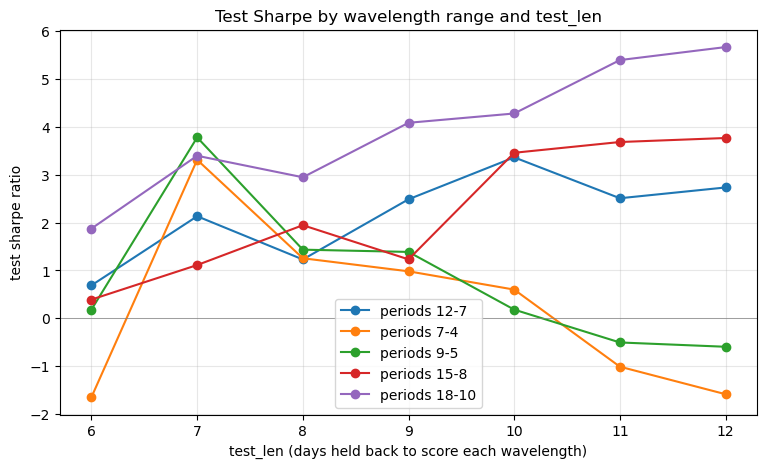

In [70]:
plt.figure(figsize=(9, 5))
for label, grp in results.groupby("periods", sort=False):
    grp = grp.sort_values("test_len")
    plt.plot(grp["test_len"], grp["test_sharpe"], marker="o", label=f"periods {label}")

plt.xlabel("test_len (days held back to score each wavelength)")
plt.ylabel("test sharpe ratio")
plt.title("Test Sharpe by wavelength range and test_len")
plt.axhline(0, color="grey", lw=0.5)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
AMPLITUDES = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

# sweep all amplitude filterings for optimal (period, test_len) combo in training set
APPROACHES = [
    (f"amplitude {a}", with_cfg(periods=list(range(15, 7, -1)), test_len=12, freq_filter="amplitude", amp_cutoff=a))
    for a in AMPLITUDES
]

# every approach must be scored on the SAME dates, so burn in on the longest
# warm-up in the list rather than each config's own
# use COMMON_WARMUP from previous experiment, instead of redefining
COMMON_WARMUP = 30

work = hdf.sort_values(["Ticker", "Date"]).copy()

SPLIT_MODE = "chronological"        # "chronological" or "random"
SEED = 42
TRAIN_FRAC = 0.5
live_dates = sorted(work["Date"].unique())[COMMON_WARMUP:]
n_train = int(len(live_dates) * TRAIN_FRAC)
if SPLIT_MODE == "chronological":
    train_dates, test_dates = live_dates[:n_train], live_dates[n_train:]
else:
    rng = np.random.default_rng(SEED)
    perm = rng.permutation(len(live_dates))
    train_dates = [live_dates[i] for i in sorted(perm[:n_train])]
    test_dates  = [live_dates[i] for i in sorted(perm[n_train:])]

rows = []
for name, cfg in APPROACHES:
    daily = run_newstrat(work, cfg)                  # daily portfolio log return, all dates
    tr, te = daily.loc[train_dates], daily.loc[test_dates]

    rows.append({
        "approach":     name,
        "amp_cutoff":   cfg['amp_cutoff'],
        "train_mean":   tr.mean(),
        "train_cum":    tr.sum(),
        "train_sharpe": sharpe_ratio(tr.mean(), tr.std()),
        "test_mean":    te.mean(),
        "test_cum":     te.sum(),
        "test_sharpe":  sharpe_ratio(te.mean(), te.std()),
        "periods":      f"{max(cfg['periods'])}-{min(cfg['periods'])}",
        "test_len":     cfg["test_len"],
    })

results = pd.DataFrame(rows)
print(f"warm-up {COMMON_WARMUP} days dropped | "
      f"train {len(train_dates)} days | test {len(test_dates)} days")
print(results.round(6).to_string(index=False))


warm-up 30 days dropped | train 41 days | test 42 days
     approach  amp_cutoff  train_mean  train_cum  train_sharpe  test_mean  test_cum  test_sharpe periods  test_len
  amplitude 0         0.0    0.000686   0.028141      3.694733   0.000649  0.027253     3.766769    15-8        12
amplitude 0.1         0.1    0.000691   0.028324      3.754940   0.000634  0.026618     3.646167    15-8        12
amplitude 0.2         0.2    0.000662   0.027132      3.743537   0.000625  0.026238     3.569818    15-8        12
amplitude 0.3         0.3    0.000630   0.025833      3.685577   0.000335  0.014064     1.993816    15-8        12
amplitude 0.4         0.4    0.000542   0.022228      3.110436   0.000332  0.013925     2.003404    15-8        12
amplitude 0.5         0.5    0.000486   0.019926      2.819566   0.000328  0.013776     1.961932    15-8        12
amplitude 0.6         0.6    0.000287   0.011750      1.733211   0.000161  0.006744     1.070980    15-8        12
amplitude 0.7         0.7

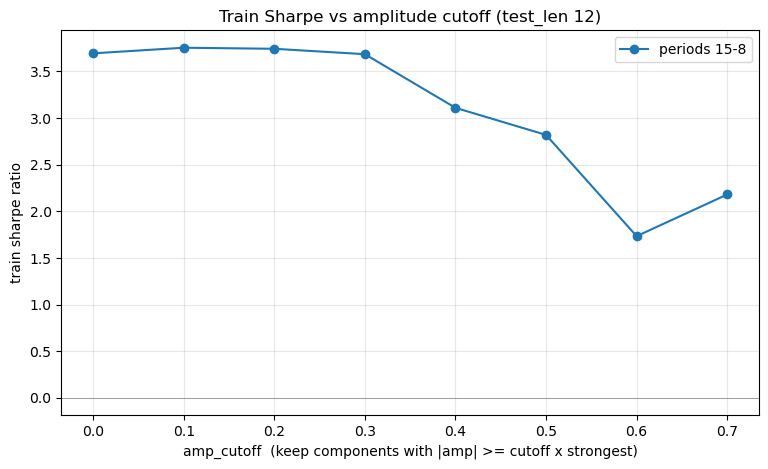

In [76]:
plt.figure(figsize=(9, 5))
for label, grp in results.groupby("periods", sort=False):
    grp = grp.sort_values("amp_cutoff")
    plt.plot(grp["amp_cutoff"], grp["train_sharpe"], marker="o", label=f"periods {label}")

plt.xlabel("amp_cutoff  (keep components with |amp| >= cutoff x strongest)")
plt.ylabel("train sharpe ratio")
plt.title(f"Train Sharpe vs amplitude cutoff (test_len {results['test_len'].iloc[0]})")
plt.axhline(0, color="grey", lw=0.5)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

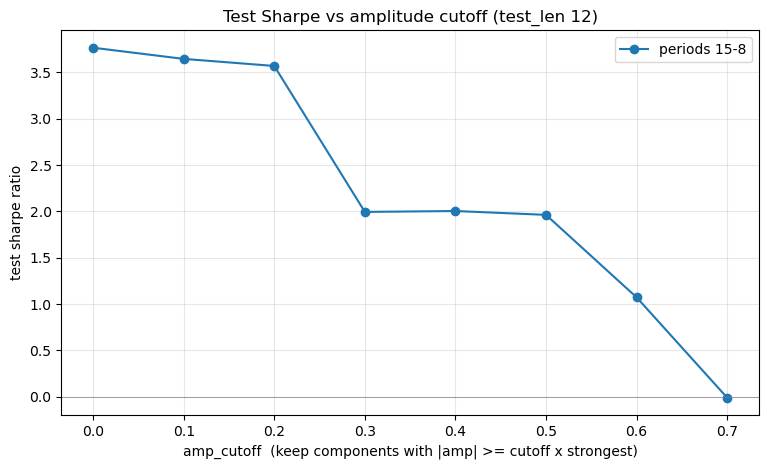

In [77]:
plt.figure(figsize=(9, 5))
for label, grp in results.groupby("periods", sort=False):
    grp = grp.sort_values("amp_cutoff")
    plt.plot(grp["amp_cutoff"], grp["test_sharpe"], marker="o", label=f"periods {label}")

plt.xlabel("amp_cutoff  (keep components with |amp| >= cutoff x strongest)")
plt.ylabel("test sharpe ratio")
plt.title(f"Test Sharpe vs amplitude cutoff (test_len {results['test_len'].iloc[0]})")
plt.axhline(0, color="grey", lw=0.5)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# ---- equal-weight benchmark on the same train/test dates ----
# equal weight has no hyperparameters, so it's a single row -- but scored on the
# identical dates, so its columns line up with results' train_cum / test_cum
eq = hdf.groupby("Date")["equal_logreturn"].sum()
tr, te = eq.loc[train_dates], eq.loc[test_dates]

equal_row = {
    "approach":     "equal weight",
    "train_mean":   tr.mean(),
    "train_cum":    tr.sum(),
    "train_sharpe": sharpe_ratio(tr.mean(), tr.std()),
    "test_mean":    te.mean(),
    "test_cum":     te.sum(),
    "test_sharpe":  sharpe_ratio(te.mean(), te.std()),
}

print(f"train {len(train_dates)} days | test {len(test_dates)} days")


train 41 days | test 42 days
    approach  train_mean  train_cum  train_sharpe  test_mean  test_cum  test_sharpe
equal weight    0.001696   0.069524      3.655703   0.001623  0.068146     4.012813
